# Visión por Computadora I - Trabajo Práctico 1

Yoharlyn Alvarez

In [1]:
%matplotlib inline

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

## Parte 1

El algoritmo White Patch asume que los valores máximos de color en los tres canales representan el color blanco bajo la luz de la escena. Luego se normalizan esos valores al color de la luz blanca pura $(255, 255, 255)$:

$$
(R,G,B) \rightarrow \left(
\frac{255}{R_{max}(I)}R,
\frac{255}{G_{max}(I)}G,
\frac{255}{B_{max}(I)}B
\right)
$$

donde $R_{max}(I)$, $G_{max}(I)$ y $B_{max}(I)$ son los valores máximos de los canales rojo, verde y azul de la imagen.

In [2]:
img_path = Path('../Material_TPs/TP1')

In [3]:
def white_patch(img):
    img_float = img.astype('float32')
    img_corregida = img_float.copy()

    for canal in range(3):
        maximo = np.max(img_float[:, :, canal])
        if maximo > 0:
            img_corregida[:, :, canal] = img_float[:, :, canal] * 255 / maximo

    img_corregida = np.clip(img_corregida, 0, 255)
    return img_corregida.astype('uint8')

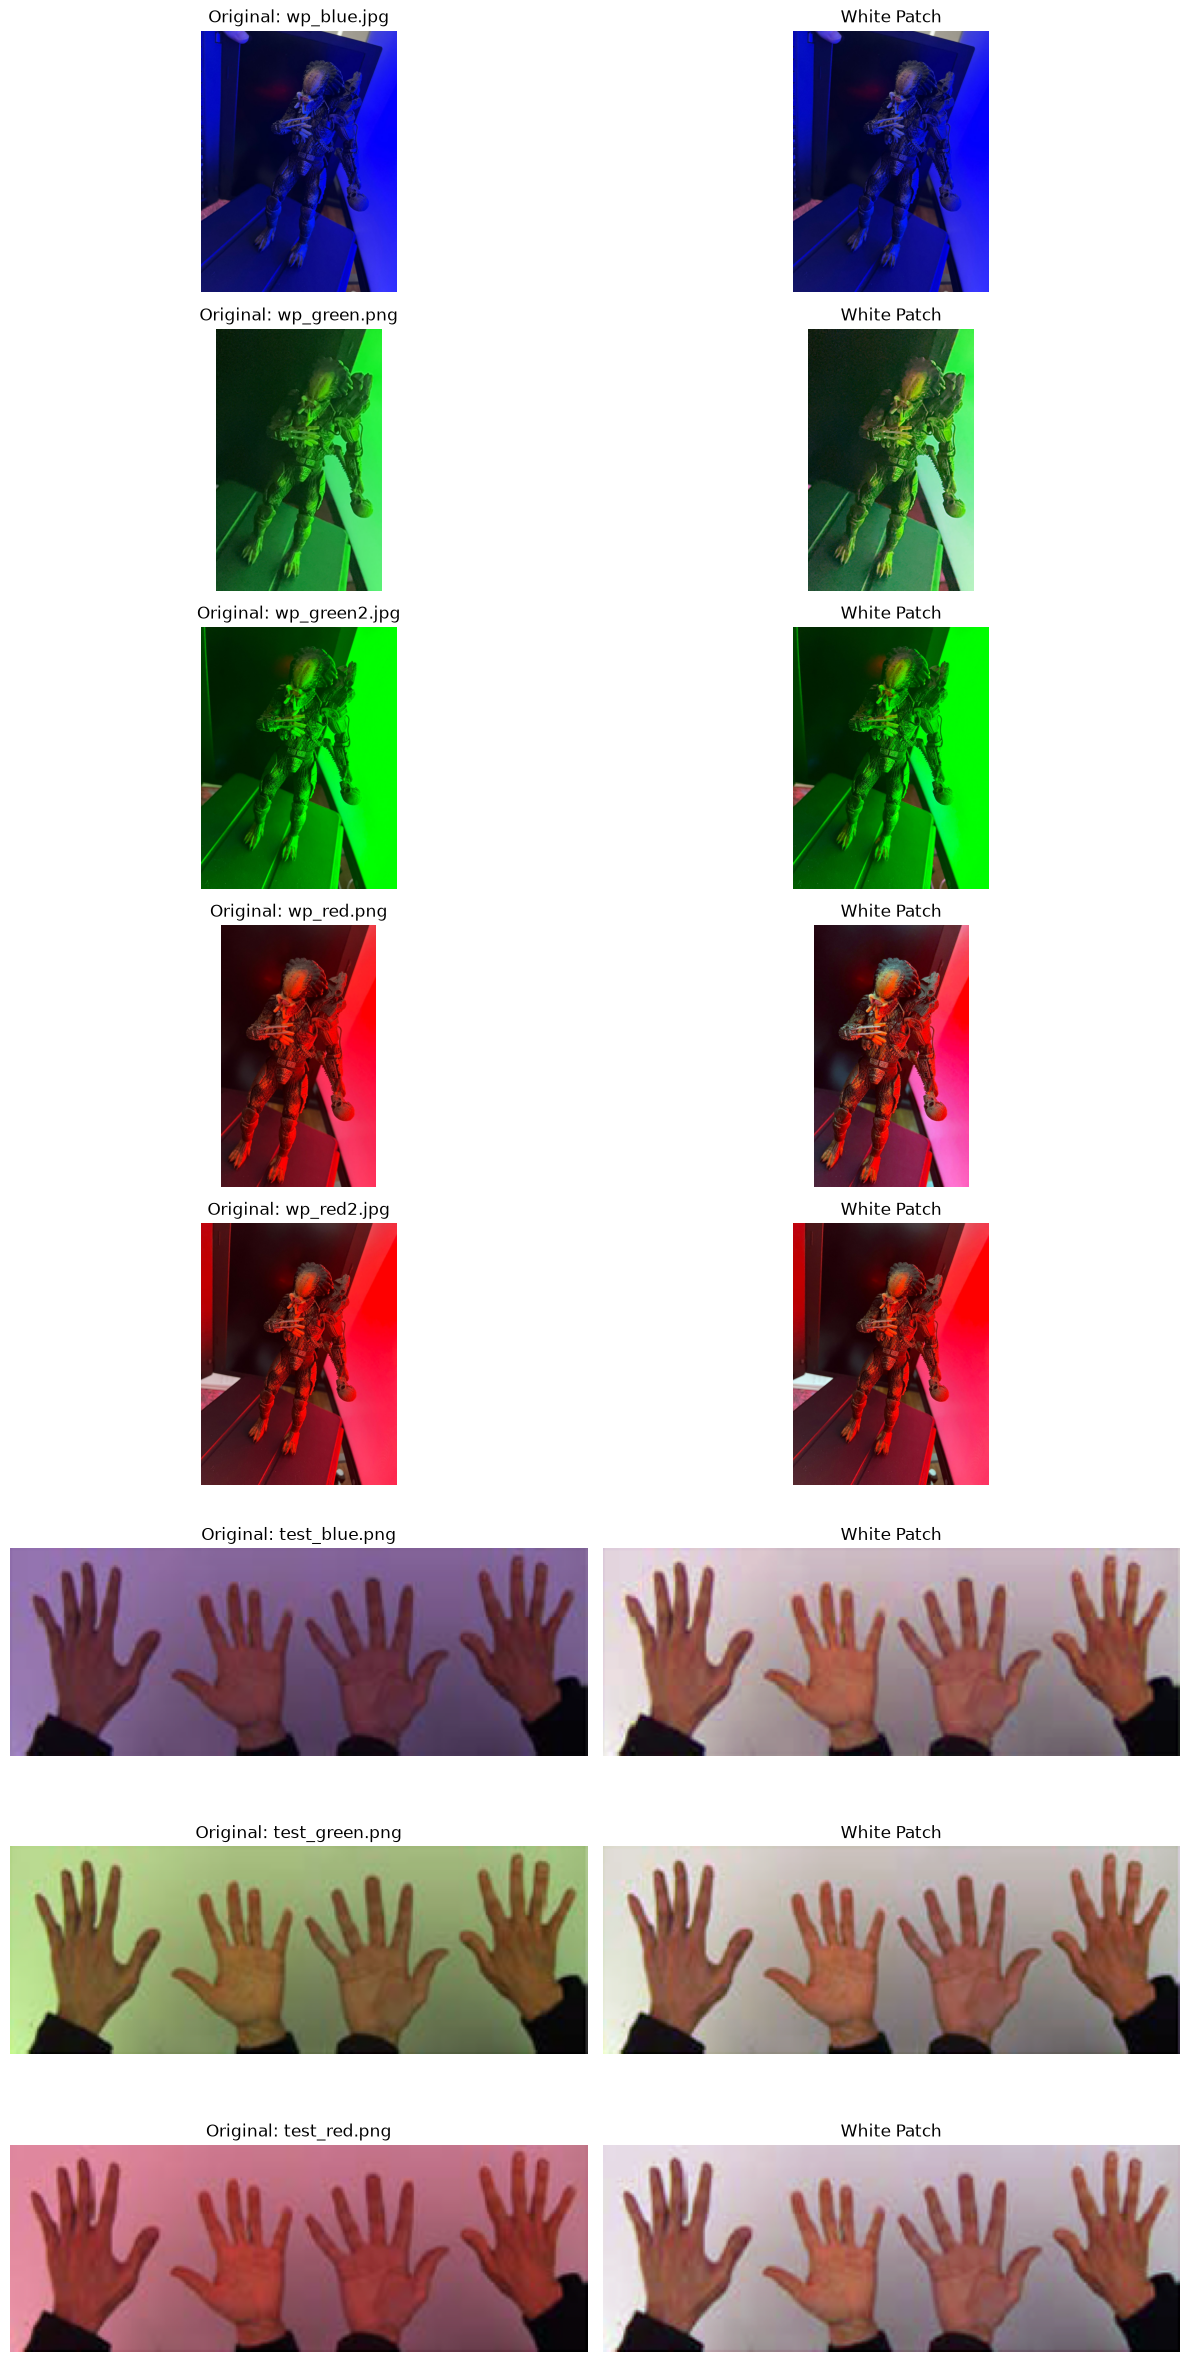

In [4]:
img_names = ['wp_blue.jpg', 'wp_green.png', 'wp_green2.jpg',
             'wp_red.png', 'wp_red2.jpg', 'test_blue.png',
             'test_green.png', 'test_red.png']

plt.figure(figsize=(12, 24))

for i, name in enumerate(img_names):
    img_bgr = cv.imread(str(img_path / 'white_patch' / name))

    img_corregida = white_patch(img_bgr)

    plt.subplot(len(img_names), 2, 2*i + 1)
    plt.imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
    plt.title(f'Original: {name}')
    plt.axis('off')

    plt.subplot(len(img_names), 2, 2*i + 2)
    plt.imshow(cv.cvtColor(img_corregida, cv.COLOR_BGR2RGB))
    plt.title('White Patch')
    plt.axis('off')

plt.tight_layout()
plt.show()

White Patch funciona correctamente en `wp_blue.jpg`, `wp_green.png`, `wp_green2.jpg`, `wp_red.png` y `wp_red2.jpg`. En estas imágenes reduce la dominante azul, verde o roja y recupera colores más naturales. Esto sucede porque contienen zonas suficientemente claras o neutras que permiten aproximar el color blanco bajo la iluminación de la escena.

En cambio, el método no funciona correctamente en `test_blue.png`, `test_green.png` y `test_red.png`. Estas imágenes no contienen una superficie realmente blanca o neutra, predominan el fondo coloreado y el color de las manos. Por lo tanto, el valor máximo de cada canal pertenece a píxeles de objetos coloreados y el algoritmo los interpreta incorrectamente como si representaran al blanco. Al escalar los canales a partir de esos máximos, modifica el balance de color sin contar con una referencia blanca válida.

Esto muestra la principal limitación de White Patch. Su resultado depende de que se cumpla el supuesto de que los máximos de los canales representan el blanco de la escena. También puede verse afectado por reflejos, zonas saturadas o píxeles aislados muy brillantes, porque utiliza directamente el valor máximo de cada canal.

## Parte 2

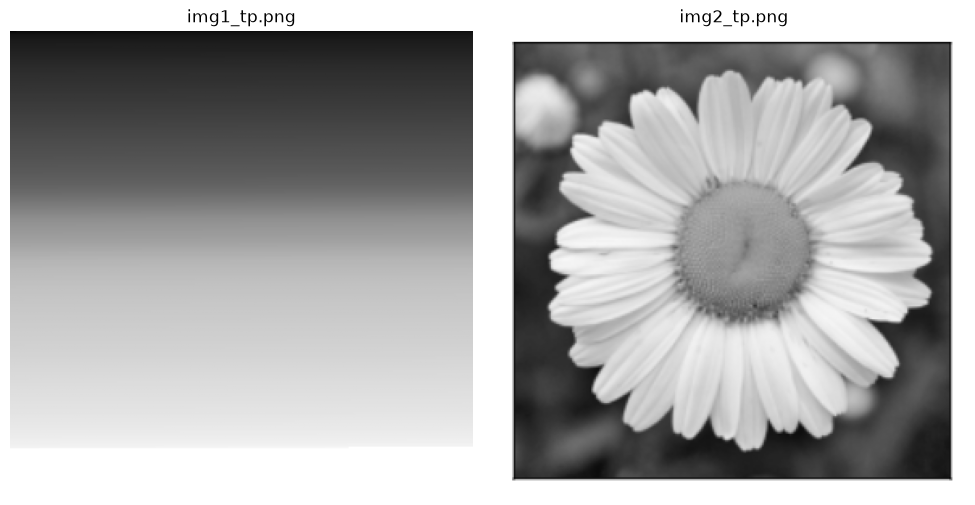

In [5]:
img1 = cv.imread(str(img_path / 'img1_tp.png'), cv.IMREAD_GRAYSCALE)
img2 = cv.imread(str(img_path / 'img2_tp.png'), cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title('img1_tp.png')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray', vmin=0, vmax=255)
plt.title('img2_tp.png')
plt.axis('off')

plt.tight_layout()
plt.show()

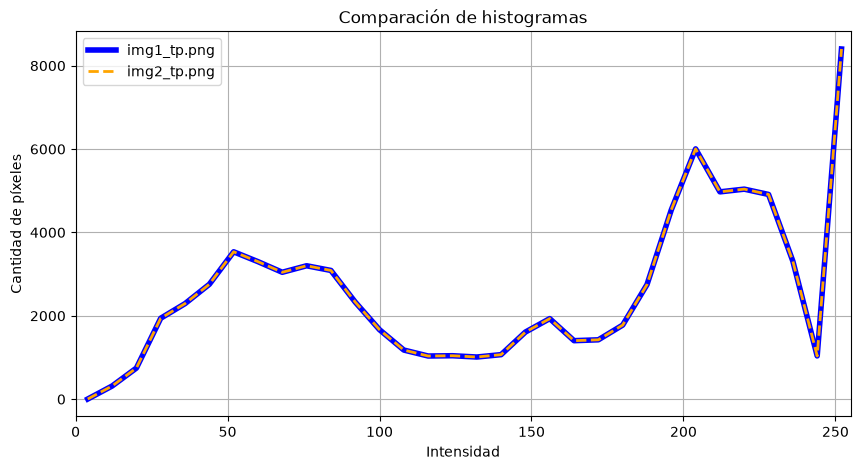

In [6]:
numero_bins = 32

hist1, bins1 = np.histogram(img1.ravel(), numero_bins, [0, 256])
hist2, bins2 = np.histogram(img2.ravel(), numero_bins, [0, 256])

centros_bins = (bins1[:-1] + bins1[1:]) / 2

plt.figure(figsize=(10, 5))

plt.plot(centros_bins, hist1, color='blue', linewidth=4, label='img1_tp.png')
plt.plot(centros_bins, hist2, color='orange', linewidth=2, linestyle='--', label='img2_tp.png')
plt.xlabel('Intensidad')
plt.ylabel('Cantidad de píxeles')
plt.title('Comparación de histogramas')
plt.xlim(0, 255)
plt.grid()
plt.legend()
plt.show()

Aunque las dos imágenes son diferentes, sus histogramas se superponen exactamente. Tienen la misma cantidad de píxeles en cada intervalo de intensidad. Esto sucede porque un histograma indica cuántos píxeles hay de cada intensidad pero no indica dónde se encuentran esos píxeles. Al cambiar la ubicación de las regiones claras y oscuras se puede obtener otra imagen conservando la misma distribución de intensidades.

Por este motivo, un histograma global puede servir como una feature sencilla cuando las clases tienen distribuciones de brillo o contraste diferentes. Sin embargo, no sería suficiente por sí solo para clasificar o detectar objetos cuya forma y posición sean importantes. Para detección resulta especialmente limitado porque se pierde toda la información espacial. Sería más útil combinarlo con otras features que describan formas, bordes o regiones de la imagen.